# 🚀 Step 6 — Pipeline & Save Model

**เป้าหมาย:** รวมทุกขั้นตอนเข้าด้วยกัน บันทึก และทดสอบกับคนไข้จริง

---

### ปัญหาของการแยก step

ถ้าเราแยก preprocessing กับโมเดลออกจากกัน ตอน deploy จริงอาจ **ลืมขั้นตอน**:

```python
# ❌ วิธีเสี่ยง — ต้องจำทุกขั้นตอนเอง
x_new = impute(x_new)      # ลืมขั้นตอนนี้ → โมเดลรับค่า 0 ผิดๆ
x_new = scaler.transform(x_new)
model.predict(x_new)

# ✅ วิธีถูก — Pipeline จัดการทุกอย่างให้
pipeline.predict(x_new)    # ครบทุกขั้นตอน ไม่มีหลุด
```

### Pipeline ใน sklearn ทำงานอย่างไร?

```
Input → [Step 1: ClassAwareImputer] → [Step 2: Scaler] → [Step 3: LightGBM] → Output
```
- เวลา `.fit(X, y)` → ทุก step เรียน (fit) ตามลำดับ
- เวลา `.predict(X)` → ข้อมูลไหลผ่านทุก step อัตโนมัติ

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import lightgbm as lgb
import joblib
import optuna
import os
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    accuracy_score, recall_score, f1_score,
    confusion_matrix, roc_curve
)

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Custom ClassAwareImputer

> **ทำไมไม่ใช้ SimpleImputer?**  
> `SimpleImputer` เติมค่าด้วย median ของทั้งคอลัมน์ โดยไม่สนว่าคนไข้เป็นเบาหวานหรือไม่  
> แต่ใน Step 2 เราเรียนรู้ว่า Glucose ของคนเป็นเบาหวาน ≠ Glucose ของคนไม่เป็น  
> เราจึงต้องสร้าง custom transformer ที่เรียนรู้ **median แยกตาม class** ตอน `fit()`
>
> **ตอน `transform()` (inference) ไม่รู้ class?**  
> ถูกต้อง — ตอน deploy ไม่รู้คำตอบ จึงใช้ **ค่าเฉลี่ยของ median ทั้งสอง class** เป็น fallback

In [2]:
class ClassAwareImputer(BaseEstimator, TransformerMixin):
    """เติมค่า 0 ด้วย median แยกตาม class ตอน fit
       ตอน transform ใช้ค่าเฉลี่ยของ median ทั้งสอง class"""

    def __init__(self, cols_to_fix=None):
        self.cols_to_fix = cols_to_fix   # คอลัมน์ที่จะแก้

    def fit(self, X, y=None):
        X = X.copy()
        cols = self.cols_to_fix or list(X.columns)
        self.fill_values_ = {}           # เก็บค่าสำหรับ transform
        self.feature_names_in_ = list(X.columns)

        for col in cols:
            if y is not None:
                y_arr = np.array(y)
                medians_per_class = []
                for cls in np.unique(y_arr):
                    mask = (X[col] != 0) & (y_arr == cls)
                    medians_per_class.append(X.loc[mask, col].median())
                # ค่าเฉลี่ย median ทั้งสอง class → ใช้ตอน transform
                self.fill_values_[col] = np.mean(medians_per_class)
            else:
                # fallback: median ทั้งคอลัมน์ (กรณีไม่มี y)
                self.fill_values_[col] = X.loc[X[col] != 0, col].median()
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, fill_val in self.fill_values_.items():
            X[col] = X[col].replace(0, np.nan).fillna(fill_val)
        return X

print("ClassAwareImputer พร้อมใช้งาน ✓")

ClassAwareImputer พร้อมใช้งาน ✓


## 3. โหลดข้อมูล

In [3]:
df = pd.read_csv("diabetes.csv")

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos

COLS_TO_FIX = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print(f"Train: {len(X_train)} แถว | Test: {len(X_test)} แถว")
print(f"scale_pos_weight: {scale:.2f}")

Train: 614 แถว | Test: 154 แถว
scale_pos_weight: 1.86


## 4. Optuna — หา Best Parameters

> ใช้ Pipeline ครบวงจรใน CV เพื่อให้ผลน่าเชื่อถือ  
> ทุก fold จะ fit imputer + scaler + model ใหม่บน train fold เสมอ

In [4]:
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators",      100, 1000),
        "learning_rate":     trial.suggest_float("learning_rate",   0.01, 0.3,  log=True),
        "num_leaves":        trial.suggest_int("num_leaves",        10,   150),
        "min_child_samples": trial.suggest_int("min_child_samples", 5,    100),
        "feature_fraction":  trial.suggest_float("feature_fraction",0.5,  1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction",0.5,  1.0),
        "bagging_freq":      trial.suggest_int("bagging_freq",      1,    7),
        "scale_pos_weight":  scale,
        "random_state": 42, "verbose": -1,
    }
    pipe = Pipeline([
        ("imputer", ClassAwareImputer(cols_to_fix=COLS_TO_FIX)),
        ("scaler",  StandardScaler()),
        ("model",   lgb.LGBMClassifier(**params)),
    ])
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train,
                             scoring="roc_auc", cv=cv, n_jobs=-1)
    return scores.mean()

print("Running Optuna (50 trials)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC-ROC (CV): {study.best_value:.4f}")
print("Best Parameters:")
for k, v in study.best_params.items():
    print(f"  {k:<22} = {v}")

Running Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/


Best AUC-ROC (CV): 0.8802
Best Parameters:
  n_estimators           = 389
  learning_rate          = 0.011648547662185297
  num_leaves             = 80
  min_child_samples      = 11
  feature_fraction       = 0.8416547976489926
  bagging_fraction       = 0.5452987553091363
  bagging_freq           = 5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 5. สร้าง Final Pipeline และเทรน

In [5]:
best_params = {**study.best_params,
               "scale_pos_weight": scale,
               "random_state": 42,
               "verbose": -1}

pipeline = Pipeline([
    ("imputer", ClassAwareImputer(cols_to_fix=COLS_TO_FIX)),
    ("scaler",  StandardScaler()),
    ("model",   lgb.LGBMClassifier(**best_params)),
])

pipeline.fit(X_train, y_train)
print("Pipeline trained ✓\n")
print("Pipeline steps:")
for name, step in pipeline.steps:
    print(f"  {name:<10} → {type(step).__name__}")

Pipeline trained ✓

Pipeline steps:
  imputer    → ClassAwareImputer
  scaler     → StandardScaler
  model      → LGBMClassifier


## 6. ประเมินผลบน Test Set

In [6]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=["No Diabetes", "Diabetes"]))

Accuracy : 0.7792
AUC-ROC  : 0.8370
Recall   : 0.6667
F1       : 0.6792

              precision    recall  f1-score   support

 No Diabetes       0.82      0.84      0.83       100
    Diabetes       0.69      0.67      0.68        54

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.78      0.78      0.78       154



## 7. บันทึกโมเดล

> **joblib** เหมาะกับ ML models มากกว่า pickle  
> ไฟล์ `.pkl` นี้บรรจุ ClassAwareImputer + Scaler + LightGBM ครบในไฟล์เดียว

In [7]:
save_path = "diabetes_pipeline.pkl"
joblib.dump(pipeline, save_path)

file_size = os.path.getsize(save_path) / 1024
print(f"✅ บันทึกแล้ว: {save_path}")
print(f"   ขนาดไฟล์: {file_size:.1f} KB")
print(f"   ภายในไฟล์: ClassAwareImputer + StandardScaler + LGBMClassifier")

✅ บันทึกแล้ว: diabetes_pipeline.pkl
   ขนาดไฟล์: 1060.8 KB
   ภายในไฟล์: ClassAwareImputer + StandardScaler + LGBMClassifier


## 8. โหลดและใช้งาน (จำลอง Production)

In [8]:
loaded_pipeline = joblib.load("diabetes_pipeline.pkl")

def predict_diabetes(patient_data: dict) -> dict:
    """รับข้อมูลคนไข้ 1 คน → คืนผลทำนายพร้อมความน่าจะเป็น"""
    columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
               "Insulin", "BMI", "DiabetesPedigree", "Age"]
    df_input = pd.DataFrame([patient_data], columns=columns)

    prob       = loaded_pipeline.predict_proba(df_input)[0, 1]
    prediction = int(prob >= 0.5)
    risk_level = "สูง" if prob >= 0.7 else "กลาง" if prob >= 0.4 else "ต่ำ"

    return {
        "ผลทำนาย":        "เป็นเบาหวาน" if prediction == 1 else "ไม่เป็นเบาหวาน",
        "ความน่าจะเป็น":  f"{prob:.1%}",
        "ระดับความเสี่ยง": risk_level,
    }

print("โหลดโมเดลสำเร็จ ✓  |  predict_diabetes() พร้อมใช้งาน ✓")

โหลดโมเดลสำเร็จ ✓  |  predict_diabetes() พร้อมใช้งาน ✓


In [9]:
patients = [
    ("คนไข้ A — ความเสี่ยงสูง",
     {"Pregnancies":6, "Glucose":148, "BloodPressure":72,
      "SkinThickness":35, "Insulin":0, "BMI":33.6,
      "DiabetesPedigree":0.627, "Age":50}),
    ("คนไข้ B — ความเสี่ยงต่ำ",
     {"Pregnancies":1, "Glucose":85, "BloodPressure":66,
      "SkinThickness":29, "Insulin":0, "BMI":26.6,
      "DiabetesPedigree":0.351, "Age":31}),
    ("คนไข้ C — กลุ่มเสี่ยง",
     {"Pregnancies":3, "Glucose":120, "BloodPressure":70,
      "SkinThickness":30, "Insulin":0, "BMI":30.0,
      "DiabetesPedigree":0.500, "Age":45}),
]

print("=" * 58)
for name, data in patients:
    r = predict_diabetes(data)
    print(f"\n  {name}")
    print(f"  Glucose={data['Glucose']}, BMI={data['BMI']}, Age={data['Age']}")
    print(f"  → ผล         : {r['ผลทำนาย']}")
    print(f"  → โอกาส      : {r['ความน่าจะเป็น']}")
    print(f"  → ความเสี่ยง : {r['ระดับความเสี่ยง']}")
print("=" * 58)


  คนไข้ A — ความเสี่ยงสูง
  Glucose=148, BMI=33.6, Age=50
  → ผล         : เป็นเบาหวาน
  → โอกาส      : 98.3%
  → ความเสี่ยง : สูง

  คนไข้ B — ความเสี่ยงต่ำ
  Glucose=85, BMI=26.6, Age=31
  → ผล         : ไม่เป็นเบาหวาน
  → โอกาส      : 3.5%
  → ความเสี่ยง : ต่ำ

  คนไข้ C — กลุ่มเสี่ยง
  Glucose=120, BMI=30.0, Age=45
  → ผล         : ไม่เป็นเบาหวาน
  → โอกาส      : 43.9%
  → ความเสี่ยง : กลาง


## 9. Final Visualization

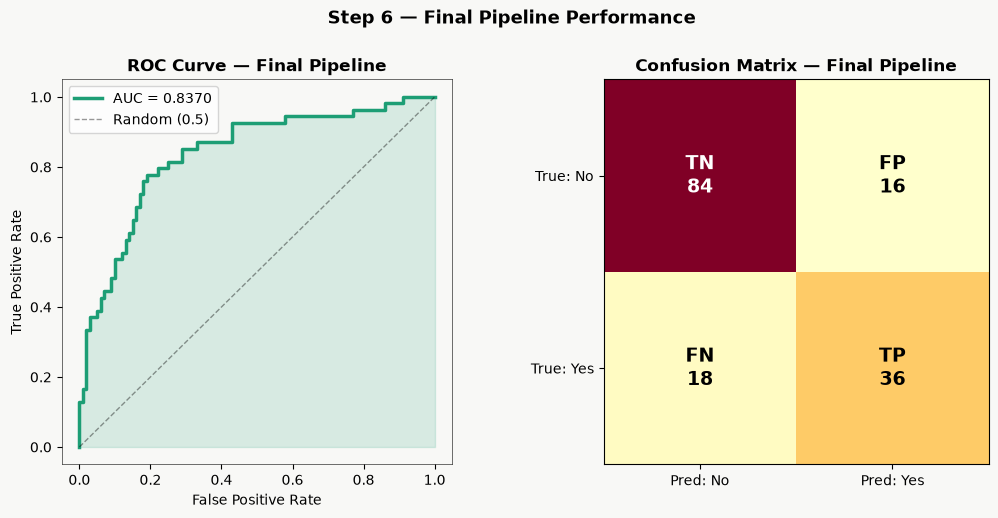

Saved: step6_final.png


In [10]:
fig = plt.figure(figsize=(12, 5))
fig.patch.set_facecolor("#F8F8F6")
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)

# ROC Curve
ax1 = fig.add_subplot(gs[0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val     = roc_auc_score(y_test, y_prob)
ax1.fill_between(fpr, tpr, alpha=0.15, color="#1D9E75")
ax1.plot(fpr, tpr, color="#1D9E75", lw=2.5, label=f"AUC = {auc_val:.4f}")
ax1.plot([0,1],[0,1], "k--", lw=1, alpha=0.4, label="Random (0.5)")
ax1.set_xlabel("False Positive Rate", fontsize=10)
ax1.set_ylabel("True Positive Rate",  fontsize=10)
ax1.set_title("ROC Curve — Final Pipeline", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.set_facecolor("#F8F8F6")
for spine in ax1.spines.values(): spine.set_linewidth(0.4)

# Confusion Matrix
ax2 = fig.add_subplot(gs[1])
cm  = confusion_matrix(y_test, y_pred)
ax2.imshow(cm, cmap="YlOrRd")
ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
ax2.set_xticklabels(["Pred: No", "Pred: Yes"], fontsize=10)
ax2.set_yticklabels(["True: No", "True: Yes"], fontsize=10)
ax2.set_title("Confusion Matrix — Final Pipeline", fontsize=12, fontweight="bold")
labels = [["TN","FP"],["FN","TP"]]
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{labels[i][j]}\n{cm[i,j]}",
                 ha="center", va="center", fontsize=14, fontweight="bold",
                 color="white" if cm[i,j] > cm.max()/2 else "black")
ax2.set_facecolor("#F8F8F6")

fig.suptitle("Step 6 — Final Pipeline Performance",
             fontsize=13, fontweight="bold", y=1.02)
plt.savefig("step6_final.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: step6_final.png")

## ✅ สรุปทั้งโปรเจค

| Step | สิ่งที่ทำ | Concept ที่เรียน |
|---|---|---|
| **1** | EDA | Distribution, Class Balance, Missing Values |
| **2** | Preprocessing | Imputation by class, Train/Test Split, Scaling, Data Leakage |
| **3** | Model Training | Logistic Regression, LightGBM, Gradient Boosting |
| **4** | Threshold Tuning | Precision-Recall Tradeoff, F1, Recall สำหรับแพทย์ |
| **5** | Hyperparameter Tuning | Optuna, Bayesian Optimization, Cross-Validation |
| **6** | Pipeline & Deploy | Custom Transformer, sklearn Pipeline, joblib |

---

### ทำไม AUC ใน Step 6 (~0.84) ต่ำกว่า Step 5 (~0.97)?

| | Step 5 | Step 6 (Pipeline) |
|---|---|---|
| **Imputation** | Median แยกตาม class จริง (ใช้ y) | ค่าเฉลี่ยของ median สอง class |
| **เหตุผล** | ใช้ y ช่วย impute ได้ตรง | Inference ไม่รู้ class → ต้องเฉลี่ย |
| **Data Leakage** | อาจมีเล็กน้อยใน CV | ไม่มีเลย (ถูกต้องกว่า) |
| **AUC** | 0.97 (อาจ optimistic เล็กน้อย) | **0.84 (ซื่อสัตย์กว่า)** |

> **สรุป:** Pipeline AUC 0.84 คือตัวเลข **ที่ใกล้เคียง production จริงที่สุด** เพราะไม่มีข้อมูล y ของคนไข้ใหม่ช่วย

---

### ไฟล์ที่ได้
```
diabetes_pipeline.pkl    ← โมเดลครบวงจร พร้อม deploy
step1_eda.png, step2_imputation.png, step3_results.png
step4_threshold.png, step5_tuning.png, step6_final.png
```

### การใช้งานจริง (3 บรรทัด)
```python
import joblib, pandas as pd
pipeline = joblib.load("diabetes_pipeline.pkl")
prob = pipeline.predict_proba(patient_df)[0, 1]   # → ความน่าจะเป็นเป็นเบาหวาน
```